In [1]:
!nvidia-smi
%cd /content
!rm -rf videomask
!git clone https://github.com/msunbot/videomask.git
%cd /content/videomask

Tue Dec 30 22:37:53 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   51C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!apt-get update -y
!apt-get install -y ffmpeg

!pip -q install -U pip
!pip -q install -e .

!pip -q install matplotlib pillow opencv-python-headless imageio[ffmpeg] numpy

!pip -q install "huggingface_hub>=0.34,<1.0" iopath regex timm tqdm einops

!pip -q install ipywidgets

Get:1 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Get:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:4 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,225 kB]
Get:5 https://cli.github.com/packages stable/main amd64 Packages [345 B]
Hit:6 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:7 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:8 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Hit:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Get:11 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Hit:12 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:13 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Pac

In [11]:
from huggingface_hub import login
login()

In [4]:
from google.colab import files
uploaded = files.upload()
print("Uploaded:", list(uploaded.keys()))

Saving demo.MOV to demo.MOV
Saving model.pt to model.pt
Saving labels.json to labels.json
Uploaded: ['demo.MOV', 'model.pt', 'labels.json']


In [5]:
import os
print(os.listdir("/content"))

['.config', 'videomask', 'sample_data']


In [6]:
# Cell 3
from pathlib import Path
import shutil, json

ROOT = Path("/content/videomask")
OUT = Path("/content/demo_out")
OUT.mkdir(parents=True, exist_ok=True)

# search both /content and repo root for uploaded files
SEARCH_DIRS = [Path("/content"), ROOT]

def find_one(names):
    for d in SEARCH_DIRS:
        for n in names:
            p = d / n
            if p.exists():
                return p
    return None

video_path = find_one(["demo.mp4", "demo.mov", "demo.MOV", "demo.mkv"])
model_pt  = find_one(["model.pt"])
labels_js = find_one(["labels.json"])

assert video_path is not None, "Upload video as demo.mp4 (preferred) or demo.mov"
assert model_pt is not None, "Upload model.pt"
assert labels_js is not None, "Upload labels.json"

# stage model artifacts into demo_out (so everything lives in one place)
model_dir = OUT / "model_artifacts"
model_dir.mkdir(parents=True, exist_ok=True)
shutil.copy(model_pt, model_dir / "model.pt")
shutil.copy(labels_js, model_dir / "labels.json")

print("video:", video_path)
print("model_pt:", model_pt)
print("labels:", labels_js)
print("model_dir:", model_dir)

video: /content/videomask/demo.MOV
model_pt: /content/videomask/model.pt
labels: /content/videomask/labels.json
model_dir: /content/demo_out/model_artifacts


sampled_frames: 18 from total_frames: 315 fps: 30.0


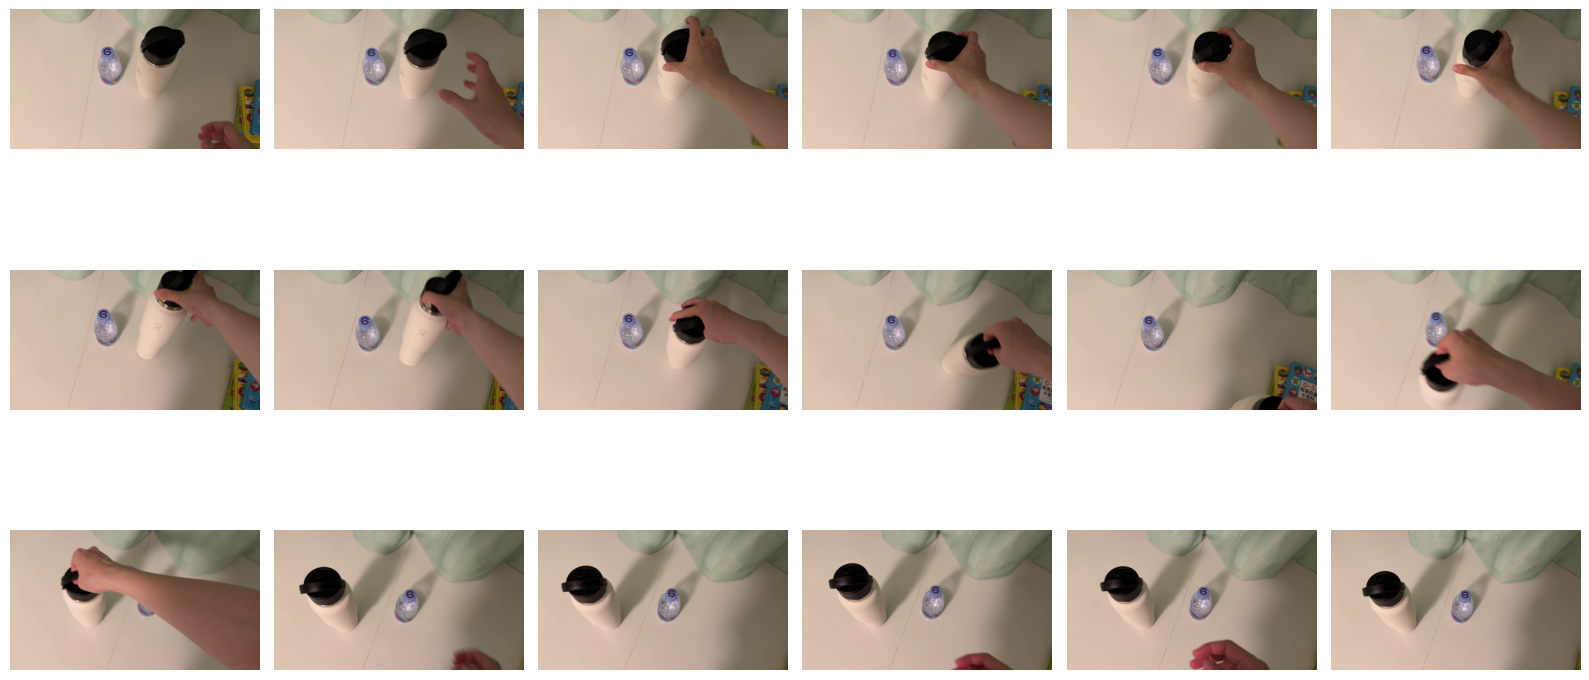

In [7]:
# Cell 4
import cv2
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

frames_dir = OUT / "frames"
frames_dir.mkdir(exist_ok=True)

cap = cv2.VideoCapture(str(video_path))
assert cap.isOpened(), "Could not open video. Try mp4."

total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT) or 0)
fps = float(cap.get(cv2.CAP_PROP_FPS) or 30.0)

N = 18  # 12–24 recommended
idxs = np.linspace(0, max(total-1, 1), N).astype(int)

frames = []
paths = []
for i, fi in enumerate(idxs):
    cap.set(cv2.CAP_PROP_POS_FRAMES, int(fi))
    ok, bgr = cap.read()
    if not ok:
        continue
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    outp = frames_dir / f"frame_{i:04d}.jpg"
    cv2.imwrite(str(outp), cv2.cvtColor(rgb, cv2.COLOR_RGB2BGR))
    frames.append(rgb)
    paths.append(outp)
cap.release()

print("sampled_frames:", len(frames), "from total_frames:", total, "fps:", fps)

# show grid
cols = 6
rows = int(np.ceil(len(frames)/cols))
plt.figure(figsize=(16, 9))
for i, img in enumerate(frames):
    plt.subplot(rows, cols, i+1)
    plt.imshow(img)
    plt.axis("off")
plt.tight_layout()
plt.show()

In [8]:
!pip install sam3 torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 197.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [sam3]


In [9]:
# Cell 5
import site, pathlib, urllib.request

# Find site-packages directory
site_pkgs = site.getsitepackages()[0]
assets_dir = pathlib.Path(site_pkgs) / "assets"
assets_dir.mkdir(parents=True, exist_ok=True)

bpe_path = assets_dir / "bpe_simple_vocab_16e6.txt.gz"

if not bpe_path.exists():
    print("Downloading CLIP BPE vocab...")
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/openai/CLIP/main/clip/bpe_simple_vocab_16e6.txt.gz",
        bpe_path,
    )
else:
    print("CLIP BPE vocab already present.")

print("BPE file:", bpe_path, "exists:", bpe_path.exists())

BPE file: /usr/local/lib/python3.12/dist-packages/assets/bpe_simple_vocab_16e6.txt.gz exists: True


config.json:   0%|          | 0.00/25.8k [00:00<?, ?B/s]

sam3.pt:   0%|          | 0.00/3.45G [00:00<?, ?B/s]

nonzero hand (first 10): [65612, 209028, 139815, 104776, 108617, 106952, 88736, 82943, 109489, 154552]
nonzero object (first 10): [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
nonzero combined (first 10): [65612, 209028, 139815, 104776, 108617, 106952, 88736, 82943, 109489, 154552]
non-empty frames (hand): 16 / 18
non-empty frames (object): 0 / 18
non-empty frames (combined): 16 / 18


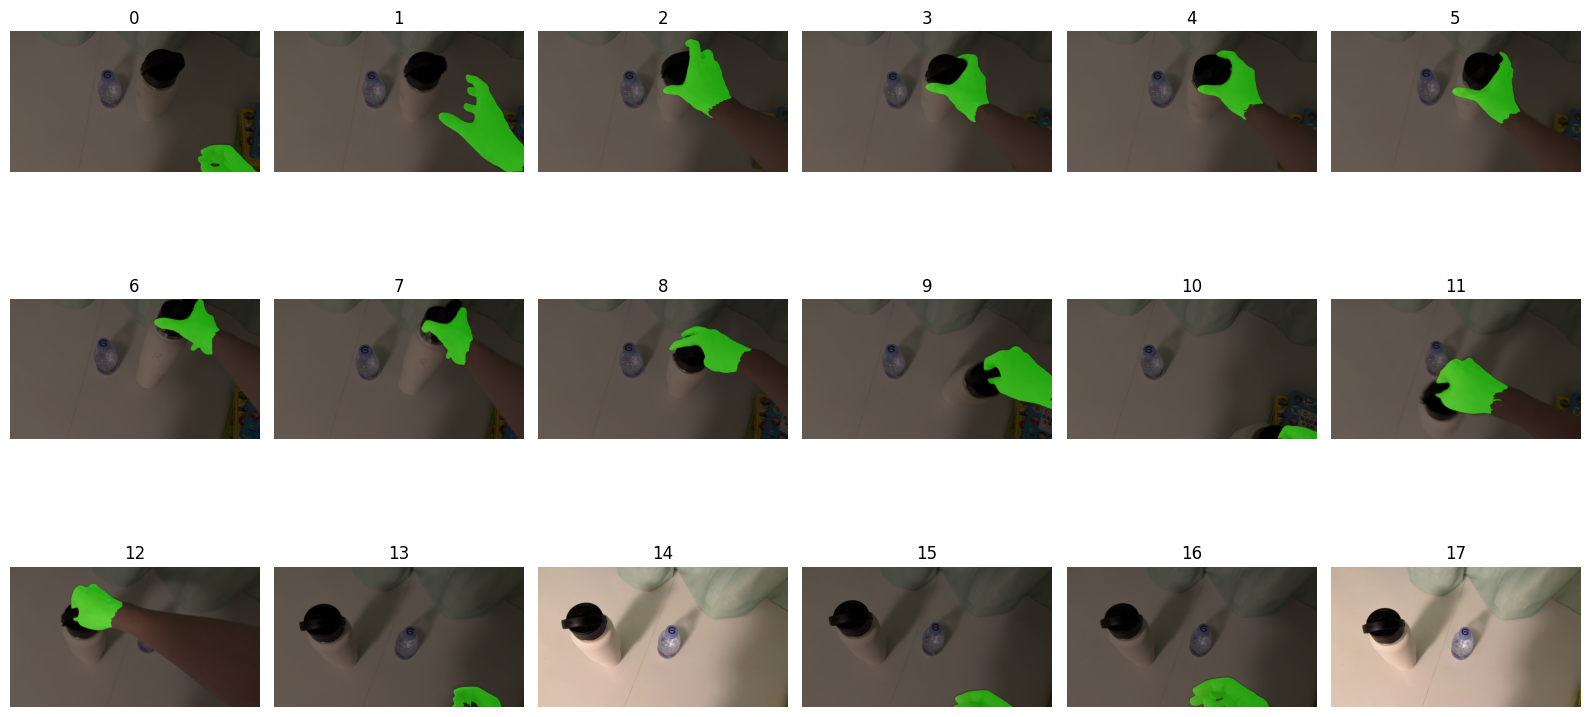

In [12]:
# Cell 6
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

from videomask.backends.sam3_backend import SAM3Backend

assert "frames" in globals() and len(frames) > 0, "Run frame sampling cell first."

sam = SAM3Backend(device="cuda", text_prompt="hand", score_threshold=0.0)
sam.load()

masks_dir = OUT / "masks"
over_dir  = OUT / "overlays"
masks_dir.mkdir(exist_ok=True)
over_dir.mkdir(exist_ok=True)

def overlay_color(rgb, mask_u8, color_rgb=(0,255,0), alpha=0.55):
    mask = (mask_u8 > 0).astype(np.uint8)
    color = np.zeros_like(rgb)
    color[...,0], color[...,1], color[...,2] = color_rgb
    out = rgb.copy()
    out = (out*(1-alpha) + color*(alpha*mask[...,None])).astype(np.uint8)
    return out

nonzero_hand = []
nonzero_obj  = []
nonzero_any  = []
overlays = []

DO_OBJECT = True  # set False if you only want hand

for i, rgb in enumerate(frames):
    # hand
    sam.text_prompt = "hand"
    mask_hand = sam.segment_frame(rgb)
    nz_h = int((mask_hand > 0).sum())
    nonzero_hand.append(nz_h)

    # object (optional)
    if DO_OBJECT:
        sam.text_prompt = "object"
        mask_obj = sam.segment_frame(rgb)
    else:
        mask_obj = np.zeros_like(mask_hand)
    nz_o = int((mask_obj > 0).sum())
    nonzero_obj.append(nz_o)

    # combined
    mask_any = np.maximum(mask_hand, mask_obj)
    nz_a = int((mask_any > 0).sum())
    nonzero_any.append(nz_a)

    # save masks (for later steps)
    Image.fromarray(mask_any).save(masks_dir / f"mask_{i:04d}.png")

    # overlay: green=hand, blue=object
    ov = rgb.copy()
    if DO_OBJECT and nz_o > 0:
        ov = overlay_color(ov, mask_obj, color_rgb=(0, 140, 255), alpha=0.45)
    if nz_h > 0:
        ov = overlay_color(ov, mask_hand, color_rgb=(0, 255, 0), alpha=0.55)

    Image.fromarray(ov).save(over_dir / f"overlay_{i:04d}.jpg")
    overlays.append(ov)

print("nonzero hand (first 10):", nonzero_hand[:10])
print("nonzero object (first 10):", nonzero_obj[:10])
print("nonzero combined (first 10):", nonzero_any[:10])
print("non-empty frames (hand):", sum(n>0 for n in nonzero_hand), "/", len(nonzero_hand))
print("non-empty frames (object):", sum(n>0 for n in nonzero_obj), "/", len(nonzero_obj))
print("non-empty frames (combined):", sum(n>0 for n in nonzero_any), "/", len(nonzero_any))

# show overlay grid
cols = 6
rows = int(np.ceil(len(overlays)/cols))
plt.figure(figsize=(16, 9))
for i, img in enumerate(overlays):
    plt.subplot(rows, cols, i+1)
    plt.imshow(img)
    plt.title(str(i))
    plt.axis("off")
plt.tight_layout()
plt.show()

assert sum(n>0 for n in nonzero_any) >= max(3, len(overlays)//6), \
    "Too many empty masks. Try changing prompt, sampling mid-clip, or reducing N."

In [13]:
# Cell 7
import json, math
import numpy as np
from pathlib import Path

from conceptops.training.model import TinyEventMLP
from conceptops.training.features import extract_window_features
from conceptops.types import FrameRecord, InstanceMask, Episode
from conceptops.perception.mask_metrics import compute_mask_stats

import torch
import torch.nn.functional as F

# Build FrameRecords with mask_quality stats (area ratio comes from mask files)
frame_records = []
for i, fp in enumerate(paths):
    mp = masks_dir / f"mask_{i:04d}.png"
    stats = compute_mask_stats(str(mp))
    inst = InstanceMask(
        instance_id=0,
        mask_path=str(mp),
        area_px=stats.area_px,
        area_ratio=stats.area_ratio,
        bbox=None,
        metadata={},
    )
    frame_records.append(
        FrameRecord(
            index=i,
            image_path=str(fp),
            mask_path=str(mp),
            timestamp_sec=float(i)/2.0,  # not critical for demo
            metadata={"mask_quality": {"area_ratio": float(stats.area_ratio), "mean_area_ratio": float(stats.area_ratio)}},
            instances=[inst],
        )
    )

# Load labels + model state_dict
labels = json.loads((model_dir/"labels.json").read_text())
if isinstance(labels, dict) and "labels" in labels:
    labels = labels["labels"]
assert isinstance(labels, list) and len(labels) > 0

model = TinyEventMLP(in_dim=7, num_classes=len(labels))
state = torch.load(str(model_dir/"model.pt"), map_location="cpu")
model.load_state_dict(state)
model.eval()

# Fixed-window proposals (honest & reliable)
T = len(frame_records)
window = 6
stride = 2

spans = []
for s in range(0, max(T-window+1, 1), stride):
    e = min(s+window, T)
    if e - s < 2:
        continue
    spans.append((s, e))

print("num_frames:", T, "num_spans:", len(spans), "window/stride:", window, stride)

# Extract features per span using repo helper
class _EpLike:
    def __init__(self, frames):
        self.frames = frames

episode_like = _EpLike(frame_records)

X = []
for (s,e) in spans:
    feats = extract_window_features(
        episode=episode_like,
        episode_dir=OUT,
        start_frame=s,
        end_frame=e,
    )
    X.append(feats)

X_t = torch.from_numpy(np.stack(X).astype(np.float32))
with torch.no_grad():
    probs = F.softmax(model(X_t), dim=1).numpy()
cls_ids = np.argmax(probs, axis=1)
scores = probs[np.arange(len(cls_ids)), cls_ids]

# Select top 3–8 spans by confidence
ranked = sorted(
    [{"start": s, "end": e, "label": labels[int(ci)], "score": float(sc)}
     for (s,e), ci, sc in zip(spans, cls_ids, scores)],
    key=lambda r: r["score"],
    reverse=True
)

events = ranked[:6]
print("events (top):")
for ev in events:
    print(ev)

assert len(events) >= 3, "Need at least 3 events; decrease stride or increase topk."

num_frames: 18 num_spans: 7 window/stride: 6 2
events (top):
{'start': 0, 'end': 6, 'label': 'manipulate', 'score': 0.4088894724845886}
{'start': 2, 'end': 8, 'label': 'manipulate', 'score': 0.40225696563720703}
{'start': 6, 'end': 12, 'label': 'manipulate', 'score': 0.3884742856025696}
{'start': 4, 'end': 10, 'label': 'manipulate', 'score': 0.38762137293815613}
{'start': 8, 'end': 14, 'label': 'manipulate', 'score': 0.37766507267951965}
{'start': 10, 'end': 16, 'label': 'manipulate', 'score': 0.3726941645145416}


Final detected events (non-overlapping):
{'start': 0, 'end': 6, 'label': 'manipulate', 'score': 0.4088894724845886}
{'start': 6, 'end': 12, 'label': 'manipulate', 'score': 0.3884742856025696}
{'start': 12, 'end': 18, 'label': 'manipulate', 'score': 0.36148276925086975}


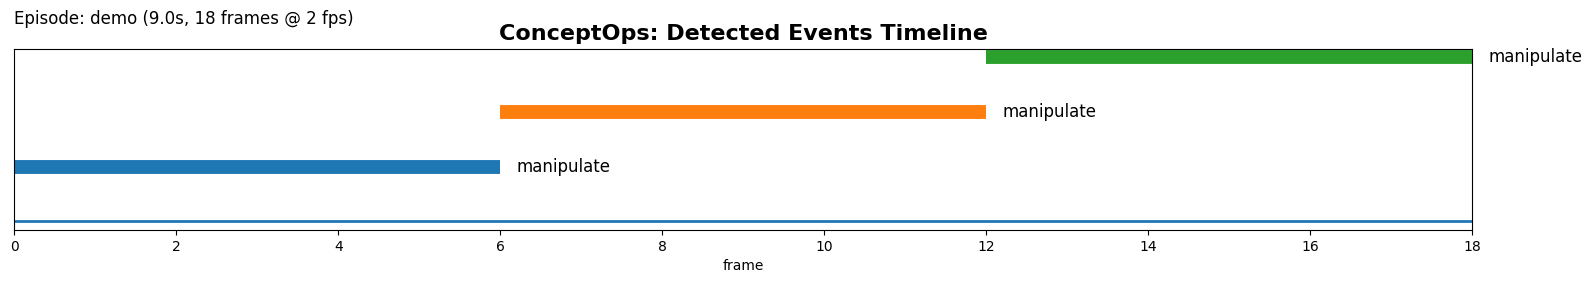

Saved: /content/demo_out/launch_detected_events_timeline.png


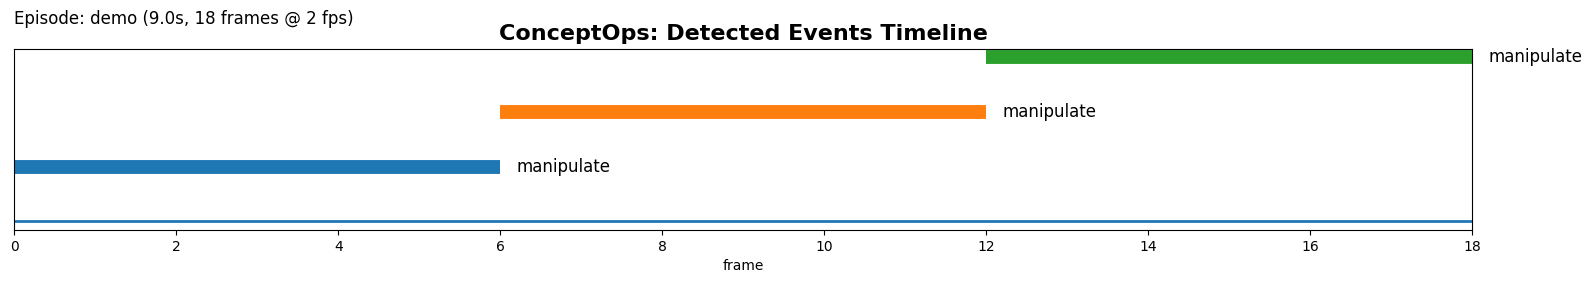

In [14]:
# newly added after Cell 7 for an improved timeline
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# --- Inputs expected from prior cells ---
# spans: List[Tuple[int,int]]
# scores: np.ndarray shape (len(spans),)
# cls_ids: np.ndarray shape (len(spans),)
# labels: List[str]
# frame_records: List[FrameRecord]
# video_path: Path
# fps (optional): float

T = len(frame_records)
K = 3  # number of final events to show (3 bars)

def overlaps(a, b):
    a_s, a_e = a
    b_s, b_e = b
    return (a_s < b_e) and (b_s < a_e)

# Build ranked candidate list (highest score first)
cands = sorted(
    [{"start": s, "end": e, "label": labels[int(ci)], "score": float(sc)}
     for (s,e), ci, sc in zip(spans, cls_ids, scores)],
    key=lambda r: r["score"],
    reverse=True
)

# Greedy non-overlap selection
final = []
for r in cands:
    span = (r["start"], r["end"])
    if all(not overlaps(span, (k["start"], k["end"])) for k in final):
        final.append(r)
    if len(final) >= K:
        break

# Sort chronologically for display
final = sorted(final, key=lambda r: r["start"])

print("Final detected events (non-overlapping):")
for r in final:
    print(r)

# --- Figure title/subtitle ---
# If you have real fps + duration from video sampling cell, use those:
fps_used = 2  # your demo extraction fps assumption
duration_s = T / fps_used
episode_name = Path(str(video_path)).stem if 'video_path' in globals() else "Episode"

title = "ConceptOps: Detected Events Timeline"
subtitle = f"Episode: {episode_name} ({duration_s:.1f}s, {T} frames @ {fps_used} fps)"

# --- Plot: clean timeline bars ---
plt.figure(figsize=(16, 3))

# baseline bar (optional)
plt.hlines(y=0, xmin=0, xmax=T, linewidth=2)

# draw event bars on separate rows
for i, r in enumerate(final):
    s, e = r["start"], r["end"]
    plt.plot([s, e], [i+1, i+1], linewidth=10, solid_capstyle="butt")
    plt.text(e + 0.2, i+1, r["label"], va="center", fontsize=12)

plt.xlim(0, T)
plt.yticks([])
plt.xlabel("frame")
plt.title(title, fontsize=16, weight="bold")
plt.text(0, max(1, len(final))+0.6, subtitle, fontsize=12)

plt.tight_layout()
plt.show()

# Save for the essay
out_path = "/content/demo_out/launch_detected_events_timeline.png"
plt.figure(figsize=(16, 3))
plt.hlines(y=0, xmin=0, xmax=T, linewidth=2)
for i, r in enumerate(final):
    s, e = r["start"], r["end"]
    plt.plot([s, e], [i+1, i+1], linewidth=10, solid_capstyle="butt")
    plt.text(e + 0.2, i+1, r["label"], va="center", fontsize=12)
plt.xlim(0, T)
plt.yticks([])
plt.xlabel("frame")
plt.title(title, fontsize=16, weight="bold")
plt.text(0, max(1, len(final))+0.6, subtitle, fontsize=12)
plt.tight_layout()
plt.savefig(out_path, dpi=200, bbox_inches="tight")
print("Saved:", out_path)

In [15]:
# Cell 8
from pathlib import Path
import json
from dataclasses import asdict

ep_dir = OUT / "episode"
ep_dir.mkdir(exist_ok=True)

# Write episode.json as a plain dict (schema-compatible)
episode_dict = {
    "episode_id": 0,
    "video": {
        "video_path": str(video_path),
        "num_frames": len(frame_records),
        "extraction_fps": 2,
        "resize_short_side": 512,
    },
    "frames": [asdict(fr) for fr in frame_records],
    "events": [
        {
            "event_id": i,
            "label": ev["label"],
            "start_frame": int(ev["start"]),
            "end_frame": int(ev["end"]),
            "score": float(ev["score"]),
            "metadata": {"source": "tiny_mlp_fixed_windows"},
        }
        for i, ev in enumerate(events)
    ],
    "extra": {
        "note": "Notebook demo: SAM3 hand masks + fixed-window proposals + TinyEventMLP",
        "proposal_method": "fixed_windows",
    },
}

(ep_dir / "episode.json").write_text(json.dumps(episode_dict, indent=2), encoding="utf-8")

pred_events = [
    {
        "event_id": i,
        "label": ev["label"],
        "start_frame": int(ev["start"]),
        "end_frame": int(ev["end"]),
        "score": float(ev["score"]),
        "metadata": {"source": "tiny_mlp_fixed_windows"},
    }
    for i, ev in enumerate(events)
]
(ep_dir / "pred_events.json").write_text(json.dumps(pred_events, indent=2), encoding="utf-8")

print("Wrote:", ep_dir/"episode.json")
print("Wrote:", ep_dir/"pred_events.json")
print("Num events:", len(pred_events))

Wrote: /content/demo_out/episode/episode.json
Wrote: /content/demo_out/episode/pred_events.json
Num events: 6


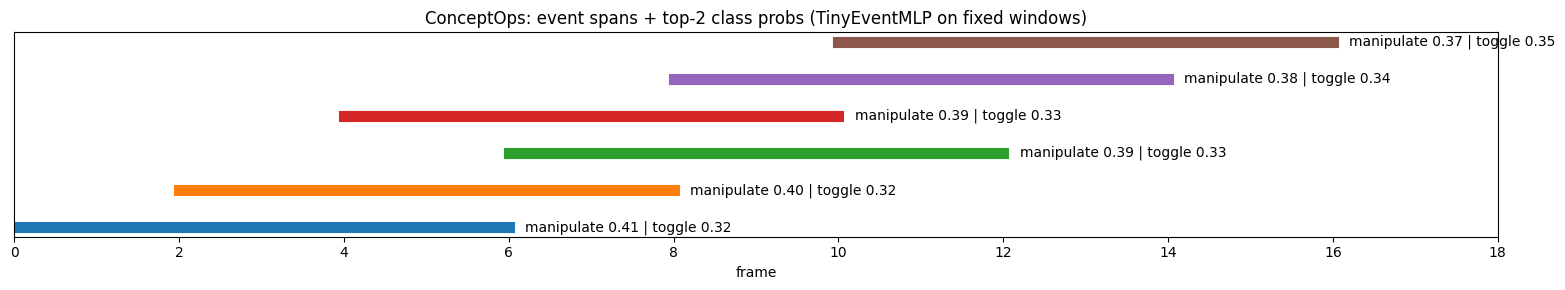

In [16]:
# Cell 9
import matplotlib.pyplot as plt
import numpy as np

# Build a mapping from span -> full prob vector
# assuming you still have: spans, probs, labels, ranked (or events list)
span_to_probs = { (s,e): p for (s,e), p in zip(spans, probs) }

plt.figure(figsize=(16, 3))
for i, ev in enumerate(pred_events):
    s, e = ev["start_frame"], ev["end_frame"]
    p = span_to_probs.get((s,e), None)
    if p is None:
        title = f"{ev['label']} ({ev['score']:.2f})"
    else:
        top2 = np.argsort(p)[::-1][:2]
        title = f"{labels[top2[0]]} {p[top2[0]]:.2f} | {labels[top2[1]]} {p[top2[1]]:.2f}"

    plt.plot([s, e], [i, i], linewidth=8)
    plt.text(e + 0.2, i, title, va="center", fontsize=10)

plt.xlim(0, len(frame_records))
plt.yticks([])
plt.xlabel("frame")
plt.title("ConceptOps: event spans + top-2 class probs (TinyEventMLP on fixed windows)")
plt.tight_layout()
plt.show()

In [17]:
# Cell 10
from pathlib import Path
import json

from conceptops.export.coco import export_episode_to_coco
from conceptops.export.rlds import export_episode_to_rlds
from conceptops.export.lerobot import export_episode_to_lerobot

coco_dir = OUT / "export_coco"
rlds_dir = OUT / "export_rlds"
lerobot_dir = OUT / "export_lerobot"
coco_dir.mkdir(exist_ok=True)
rlds_dir.mkdir(exist_ok=True)
lerobot_dir.mkdir(exist_ok=True)

coco_path = export_episode_to_coco(episode_dir=ep_dir, out_dir=coco_dir)
rlds_path = export_episode_to_rlds(episode_dir=ep_dir, out_dir=rlds_dir)
lerobot_path = export_episode_to_lerobot(episode_dir=ep_dir, out_dir=lerobot_dir)

print("COCO:", coco_path)
print("RLDS:", rlds_path)
print("LeRobot:", lerobot_path)

# prove files exist
!ls -R /content/demo_out | sed -n '1,200p'

COCO: /content/demo_out/export_coco/annotations.json
RLDS: /content/demo_out/export_rlds/rlds.json
LeRobot: /content/demo_out/export_lerobot/lerobot.json
/content/demo_out:
episode
export_coco
export_lerobot
export_rlds
frames
launch_detected_events_timeline.png
masks
model_artifacts
overlays

/content/demo_out/episode:
episode.json
pred_events.json

/content/demo_out/export_coco:
annotations.json

/content/demo_out/export_lerobot:
lerobot.json

/content/demo_out/export_rlds:
rlds.json

/content/demo_out/frames:
frame_0000.jpg
frame_0001.jpg
frame_0002.jpg
frame_0003.jpg
frame_0004.jpg
frame_0005.jpg
frame_0006.jpg
frame_0007.jpg
frame_0008.jpg
frame_0009.jpg
frame_0010.jpg
frame_0011.jpg
frame_0012.jpg
frame_0013.jpg
frame_0014.jpg
frame_0015.jpg
frame_0016.jpg
frame_0017.jpg

/content/demo_out/masks:
mask_0000.png
mask_0001.png
mask_0002.png
mask_0003.png
mask_0004.png
mask_0005.png
mask_0006.png
mask_0007.png
mask_0008.png
mask_0009.png
mask_0010.png
mask_0011.png
mask_0012.png
mask